<a href="https://colab.research.google.com/github/Zemo01/PyTorch/blob/main/Training_My_first_PyTorch_Model_%5BCard_Classifier%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
gpiosenka_cards_image_datasetclassification_path = kagglehub.dataset_download('gpiosenka/cards-image-datasetclassification')

print('Data source import complete.')


100%|██████████| 385M/385M [00:04<00:00, 98.9MB/s]

Extracting files...


Data source import complete.


# Train Your Very First Pytorch Model!


Let's learn through doing.

In this notebook we will create an image classifier to detect playing cards.

We will tackle this problem in 3 parts:
1. Pytorch Dataset
2. Pytorch Model
3. Pytorch Training Loop

Almost every pytorch model training pipeline meets this paradigm.

In [ ]:
import torch #import pytorch
import torch.nn as nn #functions related to nural networks
import torch.optim as optim #defines optimizers
from torch.utils.data import Dataset, DataLoader
import torchvision #makes working with img files easier
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm #lib for loading arch for image classification

import matplotlib.pyplot as plt # For data viz
import pandas as pd #for data exploration
import numpy as np #for data explor.
import sys
from tqdm.notebook import tqdm #used for progress bar when training

print('System Version:', sys.version)
print('PyTorch version', torch.__version__)
print('Torchvision version', torchvision.__version__)
print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)

System Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version 2.10.0+cu128
Torchvision version 0.25.0+cu128
Numpy version 2.0.2
Pandas version 2.2.2


# Step 1. Pytorch Dataset (and Dataloader)

Would you learn how to bake a cake without first having the ingredients? No.

The same thing can be said for training a pytorch model without first having the dataset setup correctly.

This is why datasets are important:
- It's an organized way to structure how the data and labels are loaded into the model.
- We can then wrap the dataset in a dataloader and pytorch will handle batching the shuffling the data for us when training the model!

In [ ]:
class PlayingCardDataset(Dataset):
    def __init__(self, data_dir, transform=None): #init tells the class what to do
        self.data = ImageFolder(data_dir, transform=transform) #transform applies to each item in the data set, used to resize the all images to the same size

    def __len__(self): #data loader needs to know how many examples in a set
        return len(self.data) #returns the length of the dataset

    def __getitem__(self, idx): #gets the index and returns one item
        return self.data[idx] #returns the image and the class when ImageFolder is called

    @property
    def classes(self):
        return self.data.classes #returns the data classes from the ImageFolder

## Create Test Dataset

In [ ]:
dataset = PlayingCardDataset(
    data_dir=gpiosenka_cards_image_datasetclassification_path + '/train'
)

In [ ]:
len(dataset)

7624

41


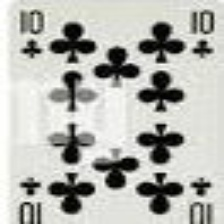

In [ ]:
image, label = dataset[6000] #pulls out the image and the label from the data set. the labels are represented by numbers for pytorch to work with
print(label)
image

In [ ]:
import os

# Get a dictionary associating target values with folder names
data_dir = os.path.join(gpiosenka_cards_image_datasetclassification_path, 'train')
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}
print(target_to_class)

{0: 'ace of clubs', 1: 'ace of diamonds', 2: 'ace of hearts', 3: 'ace of spades', 4: 'eight of clubs', 5: 'eight of diamonds', 6: 'eight of hearts', 7: 'eight of spades', 8: 'five of clubs', 9: 'five of diamonds', 10: 'five of hearts', 11: 'five of spades', 12: 'four of clubs', 13: 'four of diamonds', 14: 'four of hearts', 15: 'four of spades', 16: 'jack of clubs', 17: 'jack of diamonds', 18: 'jack of hearts', 19: 'jack of spades', 20: 'joker', 21: 'king of clubs', 22: 'king of diamonds', 23: 'king of hearts', 24: 'king of spades', 25: 'nine of clubs', 26: 'nine of diamonds', 27: 'nine of hearts', 28: 'nine of spades', 29: 'queen of clubs', 30: 'queen of diamonds', 31: 'queen of hearts', 32: 'queen of spades', 33: 'seven of clubs', 34: 'seven of diamonds', 35: 'seven of hearts', 36: 'seven of spades', 37: 'six of clubs', 38: 'six of diamonds', 39: 'six of hearts', 40: 'six of spades', 41: 'ten of clubs', 42: 'ten of diamonds', 43: 'ten of hearts', 44: 'ten of spades', 45: 'three of clu

In [ ]:
import os

transform = transforms.Compose([ #used for making the images are alwasy the same size and converted to a pytorch tensor
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

data_dir = os.path.join(gpiosenka_cards_image_datasetclassification_path, 'train')
dataset = PlayingCardDataset(data_dir, transform)

In [ ]:
image, label = dataset[100]
image.shape #to get an idea of the 3D tensor. the 3 is the number channels (Red, Green, and blue of the image) (128x128 size)

torch.Size([3, 128, 128])

In [ ]:
# iterate over dataset
for image, label in dataset:
    break

## Dataloaders

- Batching our dataset
- It's faster to train the model in batches instead of one at a time.

In [ ]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)  #batch size tells how many examples to pull every time, shuffle tells data loader to do it randomly or in order
#shuffling is generally done when training the data

In [ ]:
for images, labels in dataloader: #iterates, calling the DataLoader function
    break

In [ ]:
images.shape, labels.shape

(torch.Size([32, 3, 128, 128]), torch.Size([32]))

In [ ]:
labels

tensor([39, 21, 37, 42, 45,  9, 29, 18, 31, 16, 14, 34, 10,  6, 43, 25, 10, 21,
        46, 19, 39, 39, 25,  9, 52, 18, 27, 50, 29, 30, 40, 19])

# Step 2. Pytorch Model

Pytorch datasets have a structured way of organizing your data, pytorch models follow a similar paradigm.
- We could create the model from scratch defining each layer.
- However for tasks like image classification, many of the state of the art architectures are readily available and we can import them from packages like timm.
- Understanding the pytorch model is all about understanding the shape the data is at each layer, and the main one we need to modify for a task is the final layer. Here we have 53 targets, so we will modify the last layer for this.


In [ ]:
class SimpleCardClassifer(nn.Module):
    def __init__(self, num_classes=53): #define all the different parts of the model
        super(SimpleCardClassifer, self).__init__() #initializes this item from everything in the parent class
        # Where we define all the parts of the model
        self.base_model = timm.create_model('efficientnet_b0', pretrained=True) #b0 indicates the size of the model #efficientnet is the arch
        self.features = nn.Sequential(*list(self.base_model.children())[:-1]) #cuts off the very end of the timm model, so we can have output at the classifer level

        enet_out_size = 1280
        # Make a classifier, a linear layer from our efficientnet output size to our number of classes
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(enet_out_size, num_classes)
        )

    def forward(self, x): #
        # Connect these parts and return the output
        x = self.features(x)
        output = self.classifier(x)
        return output


In [ ]:
model = SimpleCardClassifer(num_classes=53) #creating an example
print(str(model)[:500])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

SimpleCardClassifer(
  (base_model): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=Fal


In [ ]:
example_out = model(images)
example_out.shape # [batch_size, num_classes]

torch.Size([32, 53])

# Step 3. The training loop

- Now that we understand the general paradigm of pytorch datasets and models, we need to create the process of training this model.
- Some things to consider: We want to validate our model on data it has not been trained on, so usually we split our data into a train and validate datasets (I have whole videos on this). This is easy because we can just create two datasets using our existing class.
    - Terms:
        - Epoch: One run through the entire training dataset.
        - Step: One batch of data as defined in our dataloader
- This loop is one you will become familiar with when training models, you load in data to the model in batches - then calculate the loss and perform backpropagation. There are packages that package this for you, but it's good to have at least written it once to understand how it works.
- Two things to select:
    - optimizer, `adam` is the best place to start for most tasks.
    - loss function: What the model will optimize for.


In [ ]:
# Loss function
criterion = nn.CrossEntropyLoss() #common loss function used for classification cases
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001) #pulled from pytorch optim library #Adam is really good for optimizers #lr is learning rate, in this case constant

In [ ]:
criterion(example_out, labels)
print(example_out.shape, labels.shape)

torch.Size([32, 53]) torch.Size([32])


## Setup Datasets

In [ ]:
import os

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_folder = os.path.join(gpiosenka_cards_image_datasetclassification_path, 'train')
valid_folder = os.path.join(gpiosenka_cards_image_datasetclassification_path, 'valid')
test_folder = os.path.join(gpiosenka_cards_image_datasetclassification_path, 'test') #not necessarily need for training loop

train_dataset = PlayingCardDataset(train_folder, transform=transform)
val_dataset = PlayingCardDataset(valid_folder, transform=transform)
test_dataset = PlayingCardDataset(test_folder, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) #shuffling while training
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False) #but not for validation
test_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

## Simple Training Loop

In [ ]:
# Simple training loop
num_epochs = 5 #running it 5 times, aka each Epoch,
train_losses, val_losses = [], []

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = SimpleCardClassifer(num_classes=53)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs): #loops through the training data loader
    # Training phase
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc='Training loop'): #loops through the training data loader
        # Move inputs and labels to the device
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images) #calling the foward method on the images
        loss = criterion(outputs, labels) #calculate loss
        loss.backward() #updates the models weights
        optimizer.step()
        running_loss += loss.item() * labels.size(0) #keeps track of the runs
    train_loss = running_loss / len(train_loader.dataset) #stores training loss
    train_losses.append(train_loss) #for tracking

    # Validation phase
    model.eval() #changed from training mode to eval mode
    running_loss = 0.0 #track running loss but on eval data set instead
    with torch.no_grad(): #so the model weights are not touched
        for images, labels in tqdm(val_loader, desc='Validation loop'):
            # Move inputs and labels to the device
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss}, Validation loss: {val_loss}") #lets us track how well by showing train and eval loss.


Training loop:   0%|          | 0/239 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 1/5 - Train loss: 1.5577484807087516, Validation loss: 0.45714126577917136


Training loop:   0%|          | 0/239 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

...

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 4/5 - Train loss: 0.2538130021295417, Validation loss: 0.11441759124117078


Training loop:   0%|          | 0/239 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 5/5 - Train loss: 0.19160129552451036, Validation loss: 0.1436547353582562


# Visualize Losses

We can plot our training and validation loss through this training, usually we do this at the end of each epoch. We see that our accuracy on the validation dataset is `x`! There are a LOT more things to learn about that can drastically improve how to train a model which I will cover in future videos, but this should give you a good start!



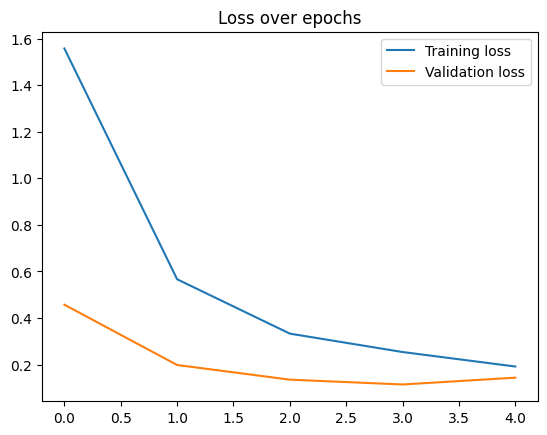

In [ ]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

# **Bonus:** Evaluating the Results



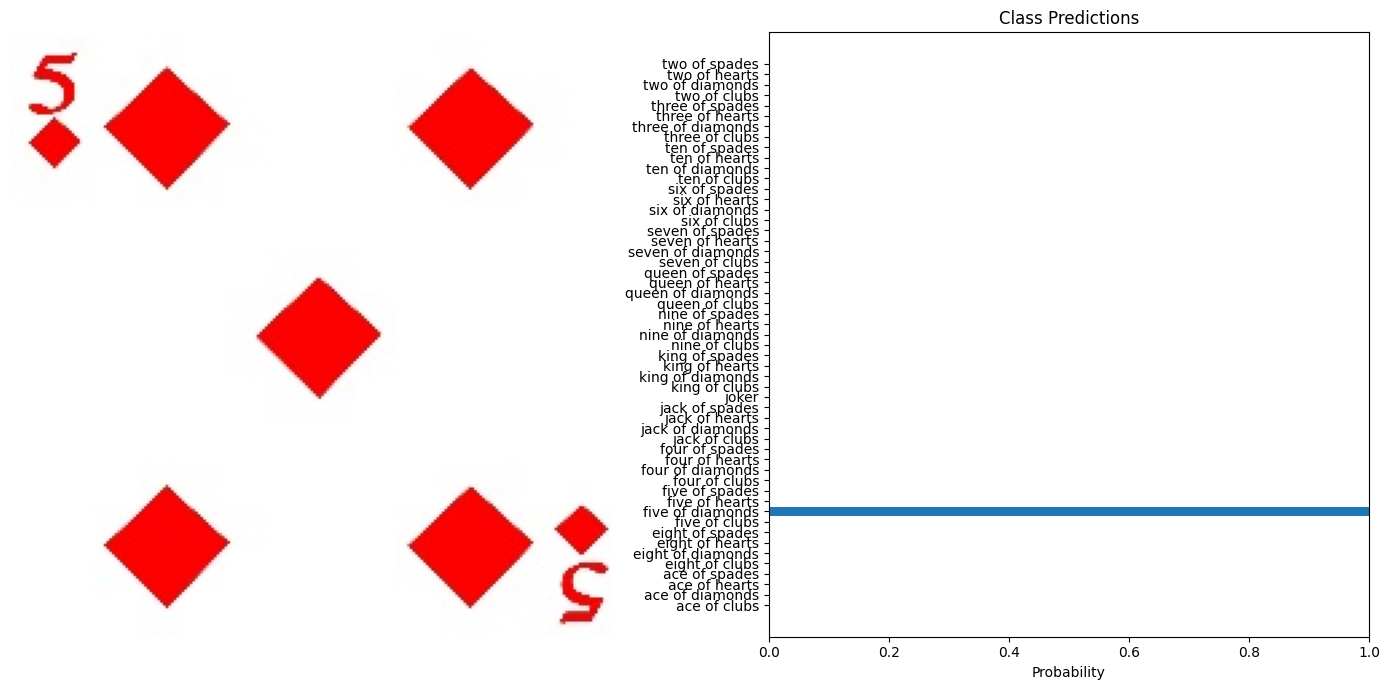

In [ ]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

# Load and preprocess the image
def preprocess_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    return image, transform(image).unsqueeze(0)

# Predict using the model
def predict(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    return probabilities.cpu().numpy().flatten()

# Visualization
def visualize_predictions(original_image, probabilities, class_names):
    fig, axarr = plt.subplots(1, 2, figsize=(14, 7))

    # Display image
    axarr[0].imshow(original_image)
    axarr[0].axis("off")

    # Display predictions
    axarr[1].barh(class_names, probabilities)
    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Predictions")
    axarr[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

# Example usage
test_image = os.path.join(test_folder, 'five of diamonds', '2.jpg')
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

original_image, image_tensor = preprocess_image(test_image, transform)
probabilities = predict(model, image_tensor, device)

# Assuming dataset.classes gives the class names
class_names = dataset.classes
visualize_predictions(original_image, probabilities, class_names)

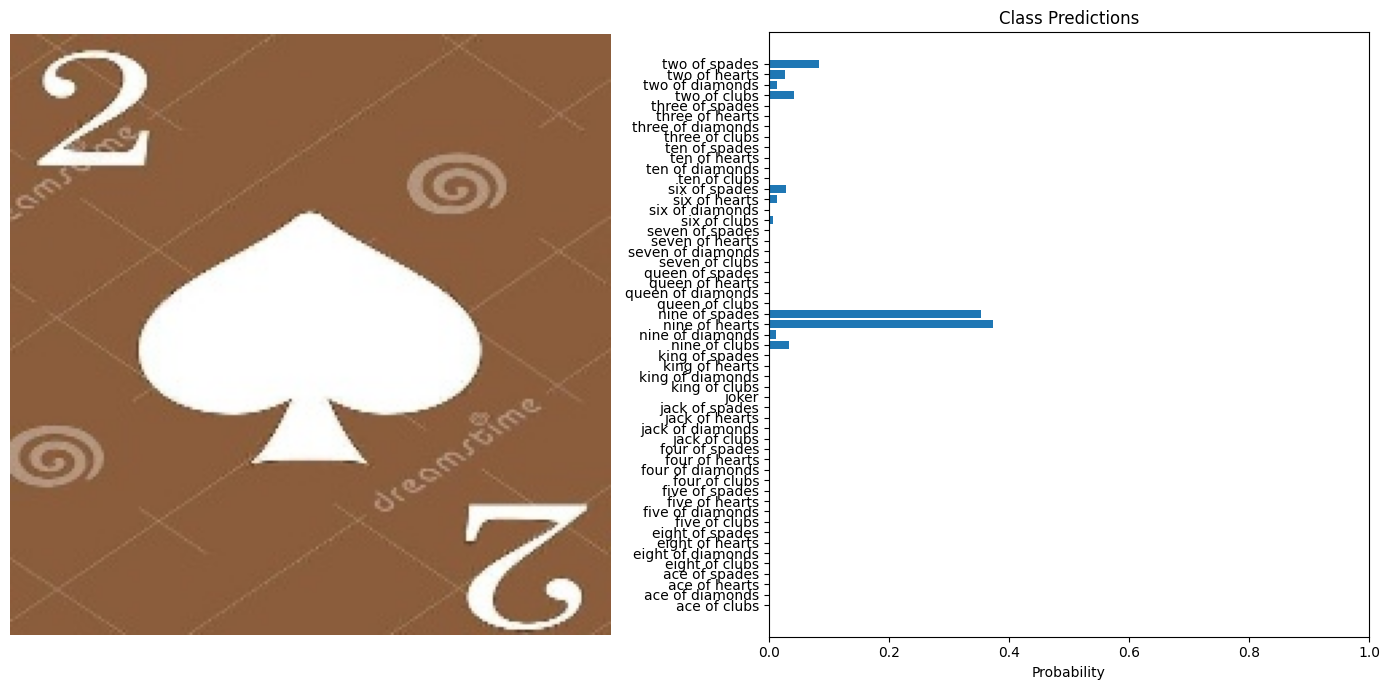

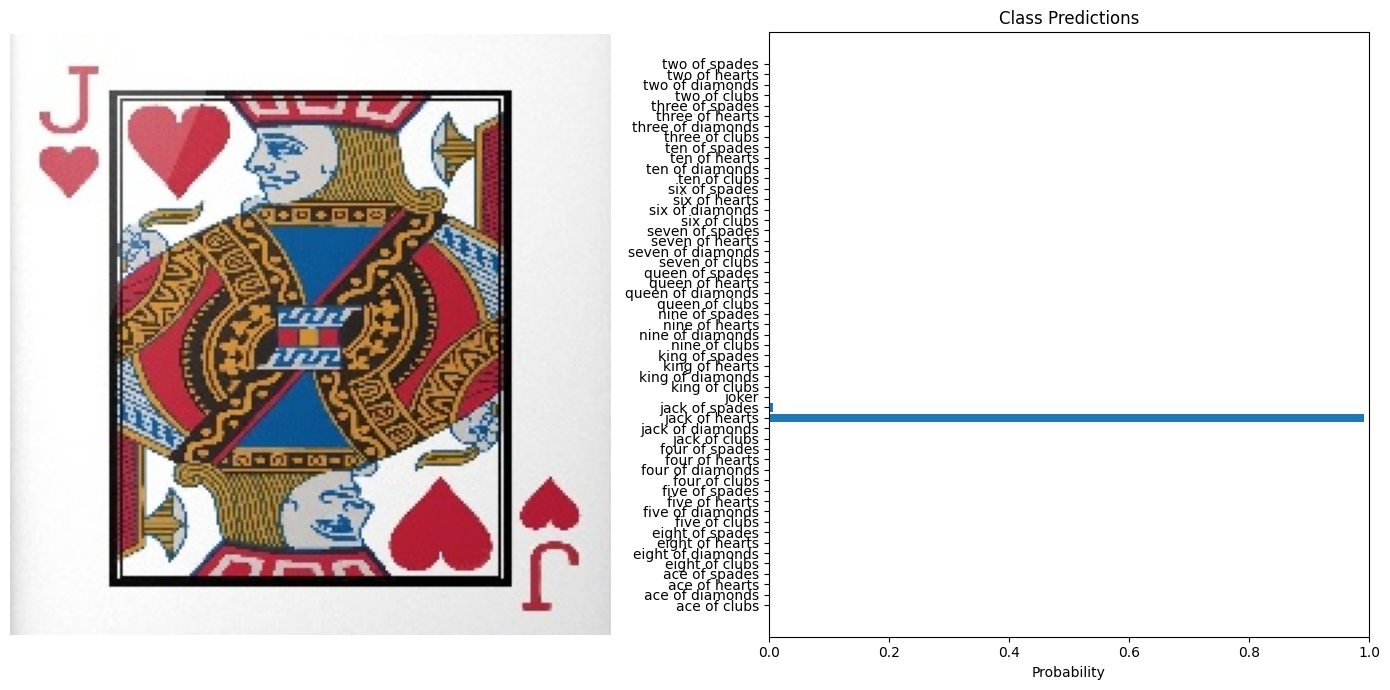

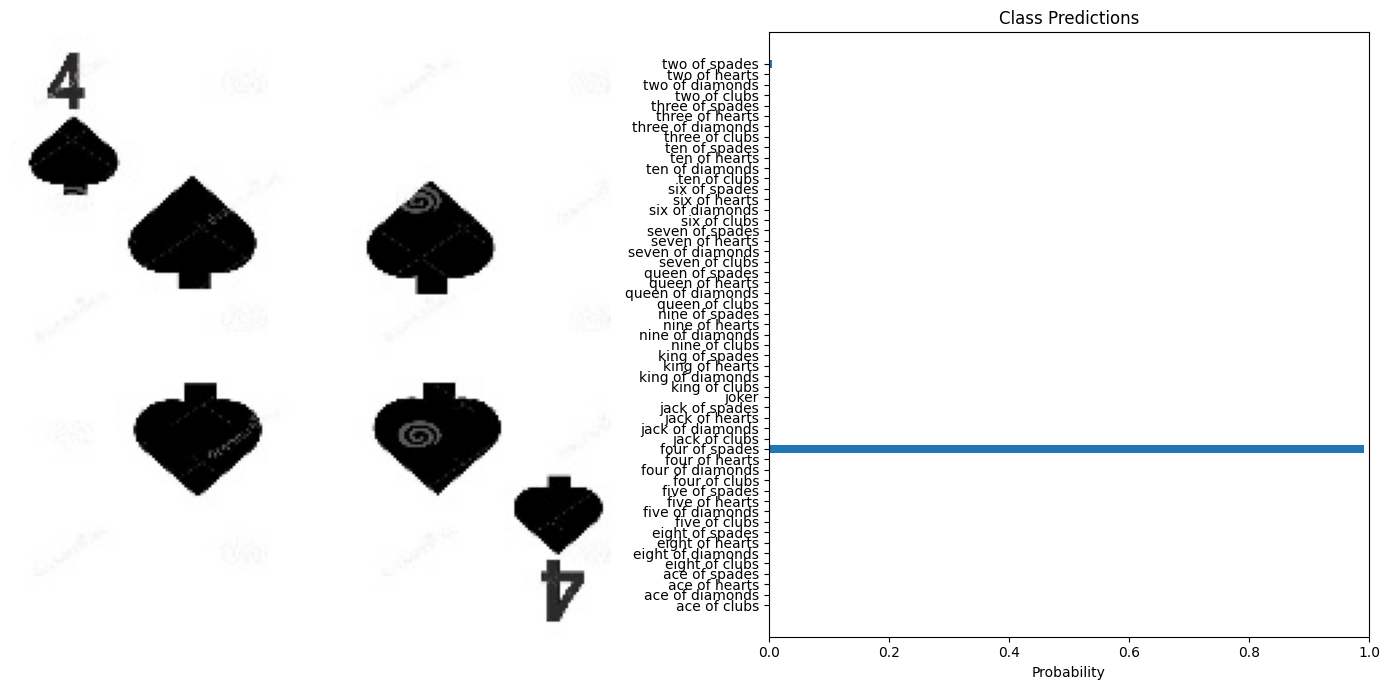

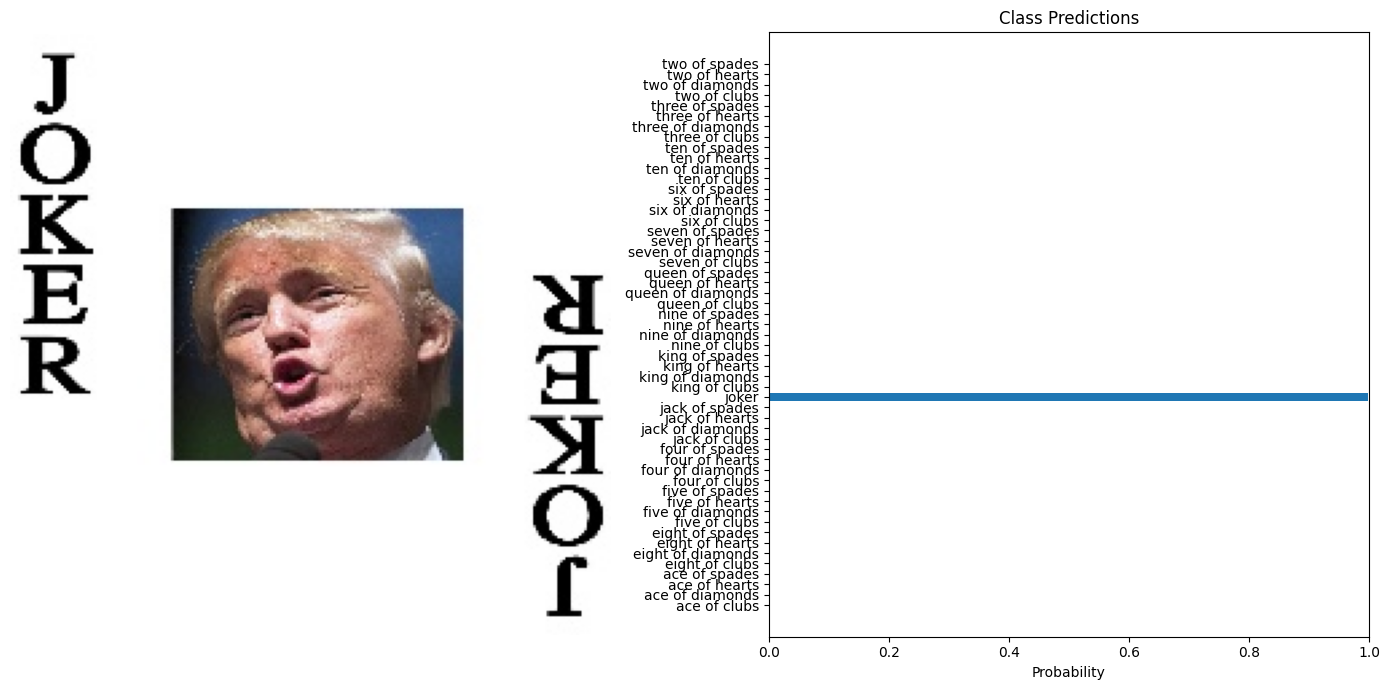

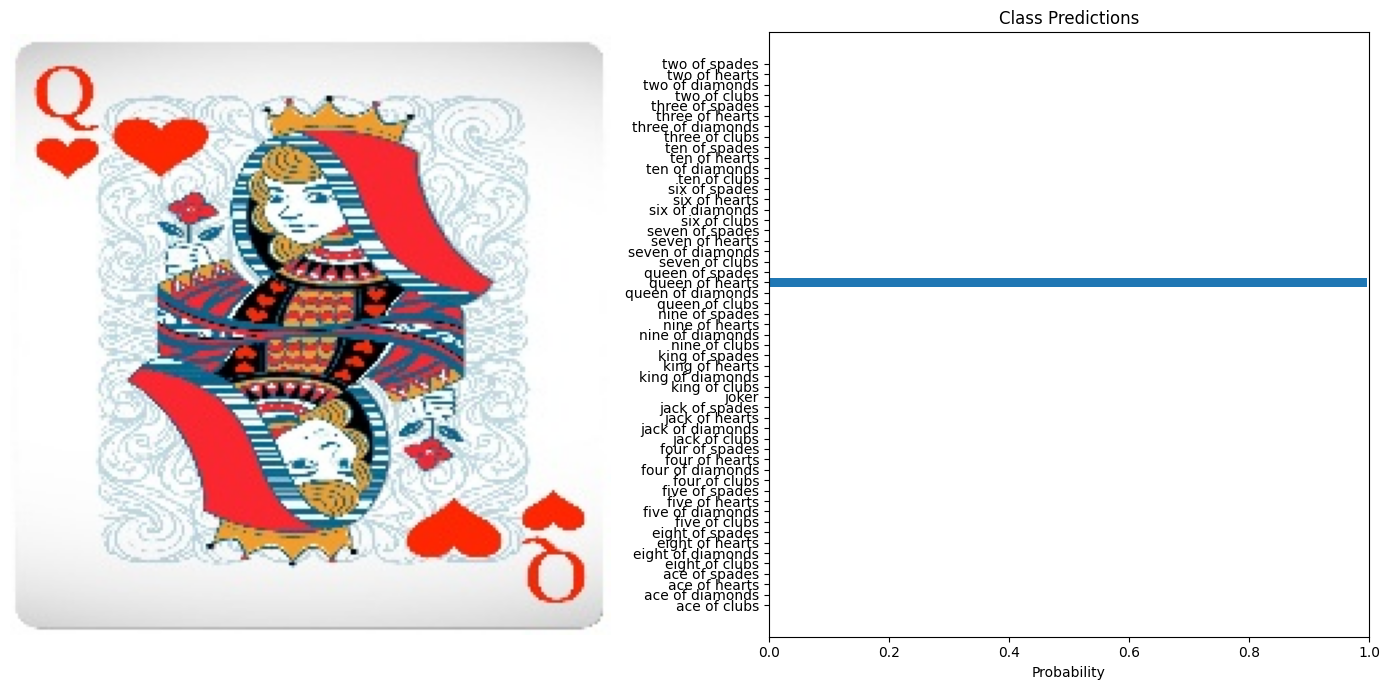

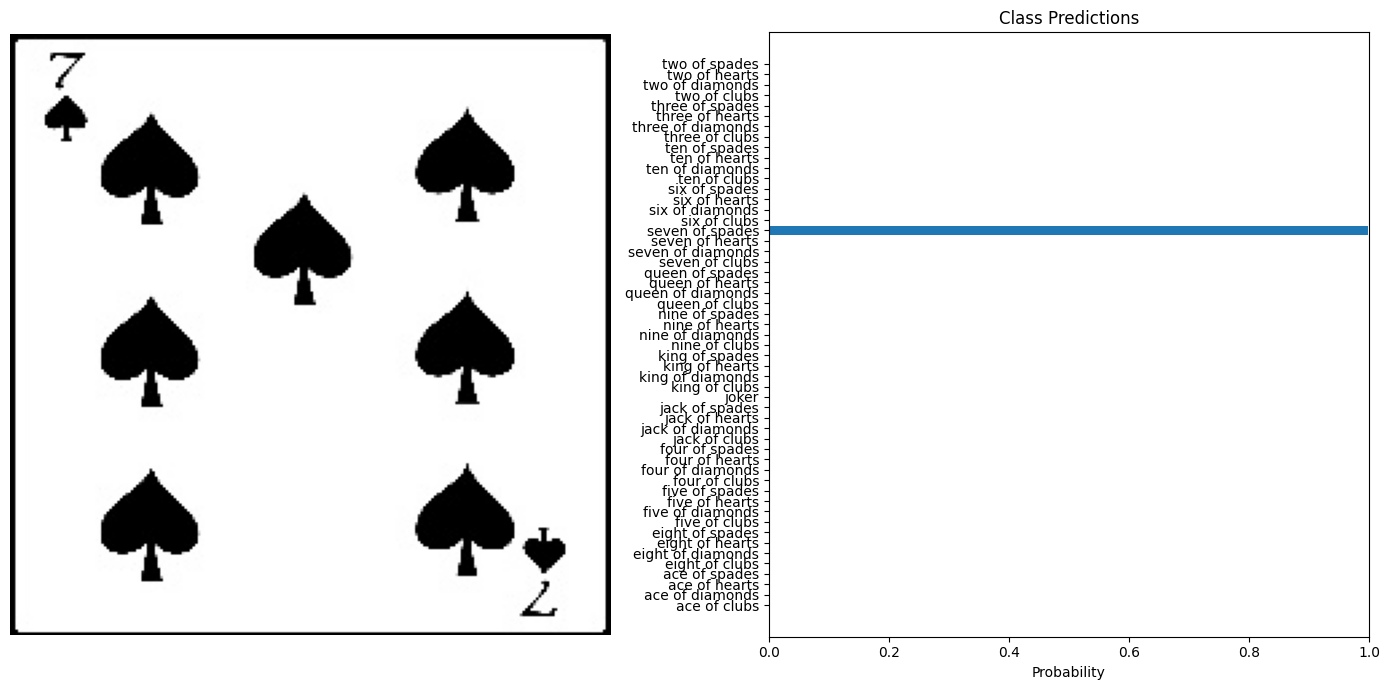

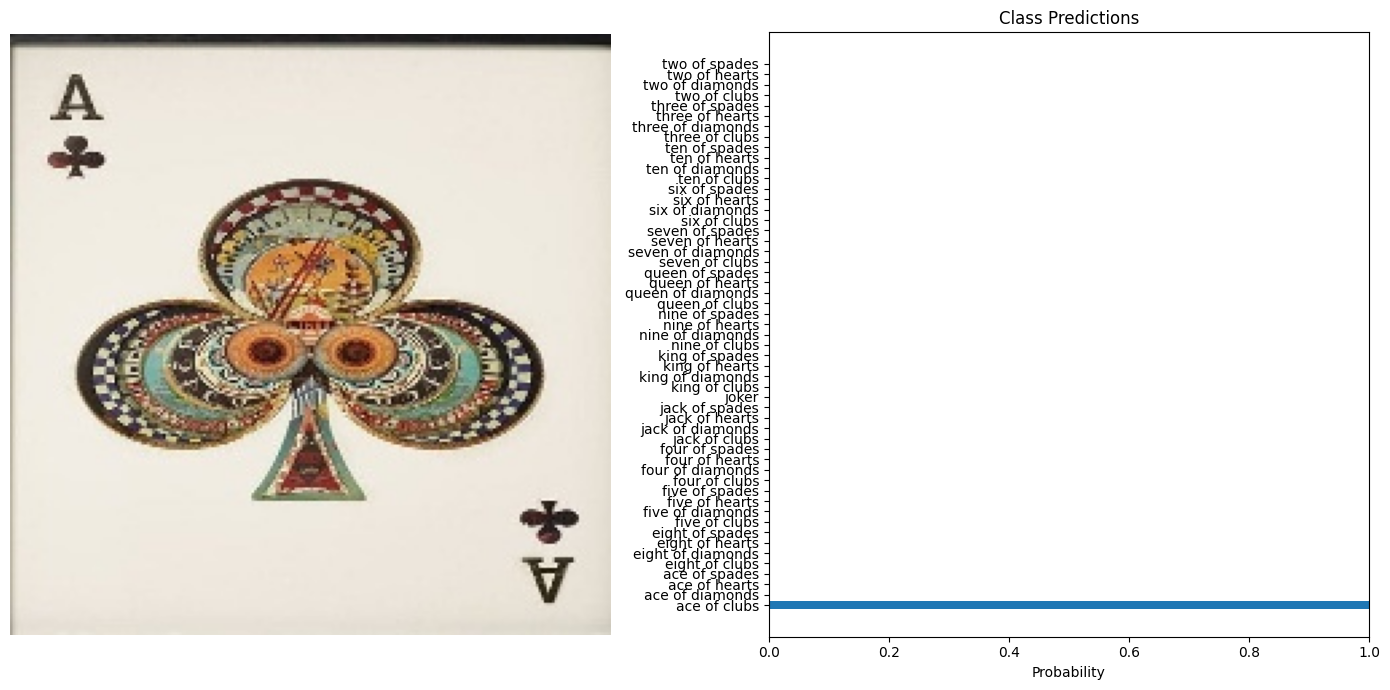

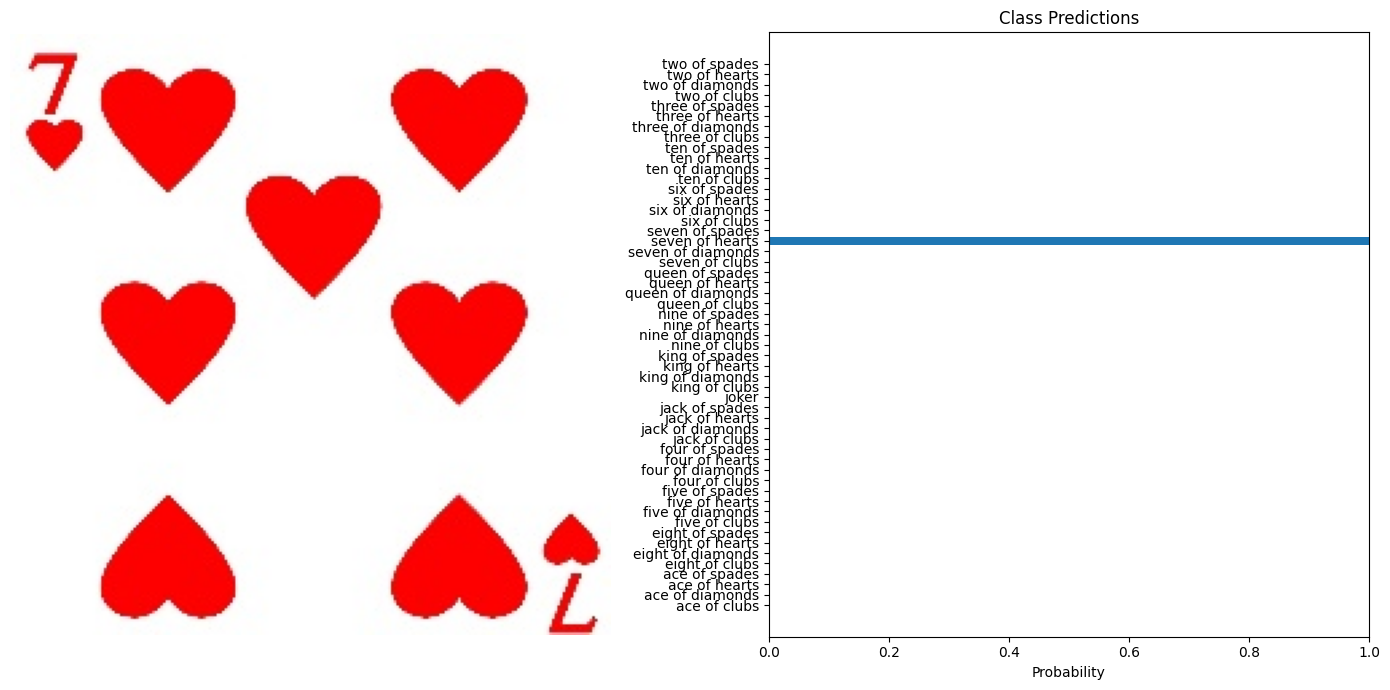

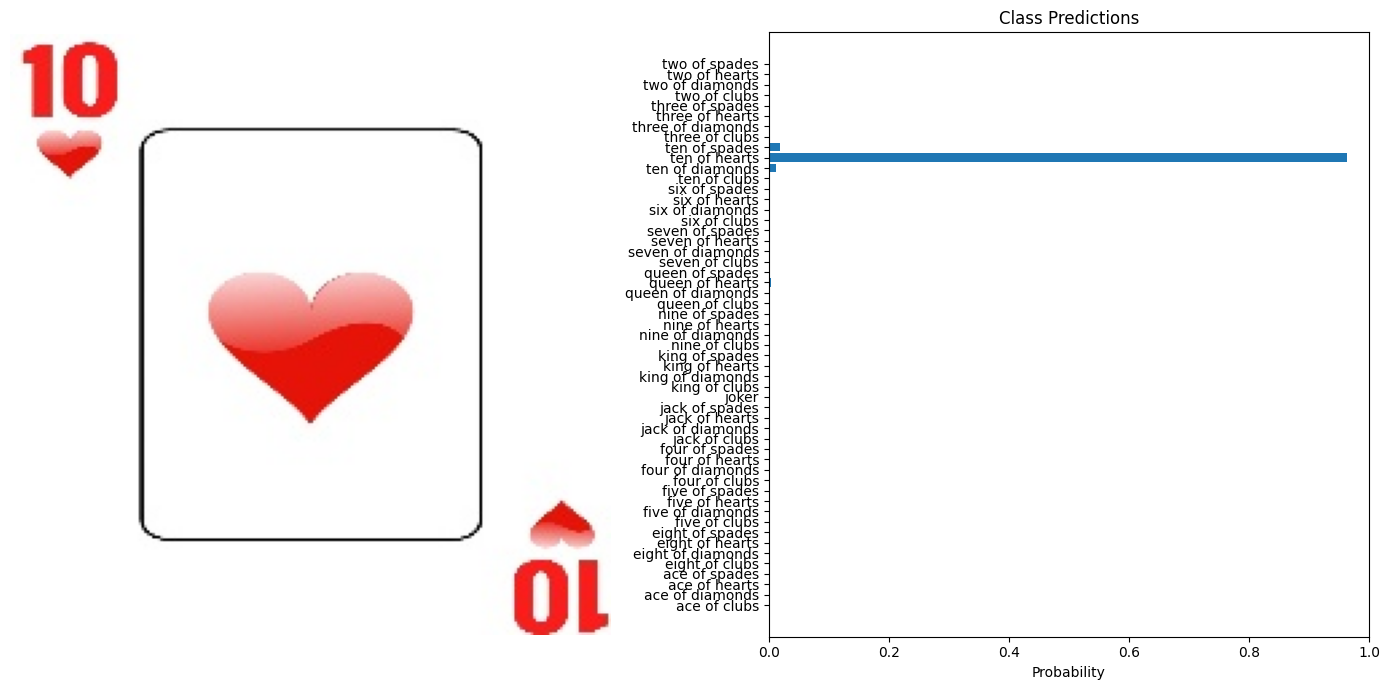

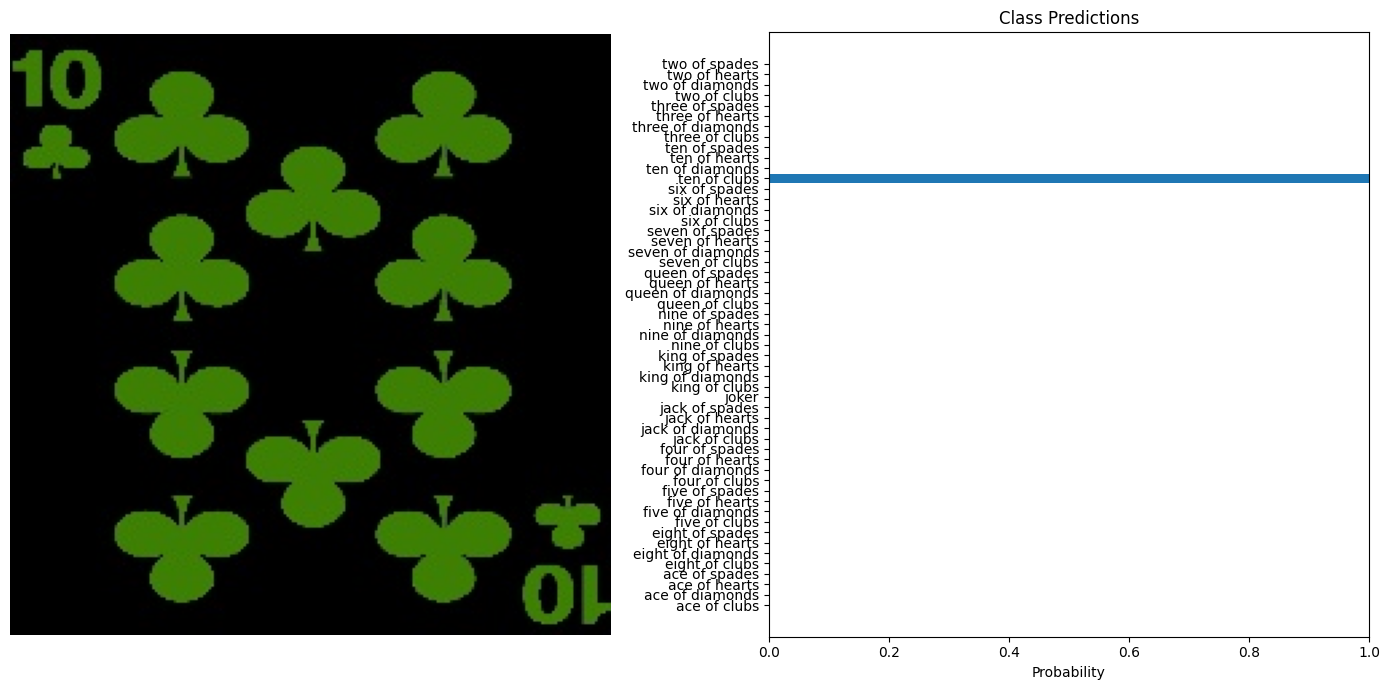

In [ ]:
from glob import glob
import os

test_images = glob(os.path.join(test_folder, '*/*')) #used to select the random images
test_examples = np.random.choice(test_images, 10) #printing 10 test examples #numpy used to sample them

for example in test_examples:
    original_image, image_tensor = preprocess_image(example, transform)
    probabilities = predict(model, image_tensor, device)

    # Assuming dataset.classes gives the class names
    class_names = dataset.classes
    visualize_predictions(original_image, probabilities, class_names)

# Todo

- Calculate the accuracy of our model on the validation and test set.

To find the correct path for your notebook file in Colab, you can list the files and directories in your current working directory. The output will show you available files and their paths.

Run the following code cell to list the contents of your current directory. If your notebook is in a subdirectory, you might need to navigate there or use a more specific path.

In [11]:
# Use the !ls -F command to list files and folders in the current directory.
# Directories will have a '/' at the end.
# You can also use `!ls -R` to list recursively.
!ls -F


 sample_data/  'Training_My_first_PyTorch_Model_[Card_Classifier].ipynb'


After running the `!ls -F` command, look for your notebook file (e.g., `Training_My_first_PyTorch_Model_[Card_Classifier].ipynb`). If it's not in the root directory, it might be in a subdirectory. If you locate it, update the `notebook_filename` variable in the previous cell (`fn2d2u5q7k3T`) with the correct path, for example, `"path/to/your/notebook.ipynb"`.

In [12]:
import nbformat
import os

notebook_filename = "Training_My_first_PyTorch_Model_[Card_Classifier].ipynb" # Update this with the correct path if your notebook is elsewhere

if not os.path.exists(notebook_filename):
    print(f"Error: The file '{notebook_filename}' was not found.")
    print("Please ensure the notebook file exists in the correct directory or update the 'notebook_filename' variable with the correct path.")
    print("If you intend to modify the *current* notebook, you may need to save it first and then refer to its saved path.")
else:
    nb = nbformat.read(notebook_filename, as_version=nbformat.NO_CONVERT)
    if "widgets" in nb.metadata and "state" not in nb.metadata.widgets:
      nb.metadata["widgets"] = {"state": {}}
    nbformat.write(nb, "notebook_fixed.ipynb")